In [2]:
from keras.utils import to_categorical
from keras_preprocessing.image import load_img
from keras.models import Sequential
from keras.layers import Dense, Conv2D, Dropout, Flatten, MaxPooling2D
import os
import pandas as pd
import numpy as np

In [3]:
TRAIN_DIR = 'images/train'
TEST_DIR = 'images/test'

In [4]:
def createdataframe(dir):
    image_paths = []
    labels = []
    for label in os.listdir(dir):
        for imagename in os.listdir(os.path.join(dir,label)):
            image_paths.append(os.path.join(dir,label,imagename))
            labels.append(label)
        print(label, "completed")
    return image_paths,labels

In [5]:
train = pd.DataFrame()
train['image'], train['label'] = createdataframe(TRAIN_DIR)

angry completed
disgust completed
fear completed
happy completed
neutral completed
sad completed
surprise completed


In [6]:
print(train)

                                image     label
0            images/train\angry\0.jpg     angry
1            images/train\angry\1.jpg     angry
2           images/train\angry\10.jpg     angry
3        images/train\angry\10002.jpg     angry
4        images/train\angry\10016.jpg     angry
...                               ...       ...
28816  images/train\surprise\9969.jpg  surprise
28817  images/train\surprise\9985.jpg  surprise
28818  images/train\surprise\9990.jpg  surprise
28819  images/train\surprise\9992.jpg  surprise
28820  images/train\surprise\9996.jpg  surprise

[28821 rows x 2 columns]


In [7]:
test = pd.DataFrame()
test['image'], test['label'] = createdataframe(TEST_DIR)

angry completed
disgust completed
fear completed
happy completed
neutral completed
sad completed
surprise completed


In [8]:
print(test)
print(test['image'])

                              image     label
0       images/test\angry\10052.jpg     angry
1       images/test\angry\10065.jpg     angry
2       images/test\angry\10079.jpg     angry
3       images/test\angry\10095.jpg     angry
4       images/test\angry\10121.jpg     angry
...                             ...       ...
7061  images/test\surprise\9806.jpg  surprise
7062  images/test\surprise\9830.jpg  surprise
7063  images/test\surprise\9853.jpg  surprise
7064  images/test\surprise\9878.jpg  surprise
7065   images/test\surprise\993.jpg  surprise

[7066 rows x 2 columns]
0         images/test\angry\10052.jpg
1         images/test\angry\10065.jpg
2         images/test\angry\10079.jpg
3         images/test\angry\10095.jpg
4         images/test\angry\10121.jpg
                    ...              
7061    images/test\surprise\9806.jpg
7062    images/test\surprise\9830.jpg
7063    images/test\surprise\9853.jpg
7064    images/test\surprise\9878.jpg
7065     images/test\surprise\993.jpg
Name:

In [9]:
from tqdm import tqdm
import numpy as np
from tensorflow.keras.preprocessing.image import load_img

def extract_features(images):
    features = []
    for image in tqdm(images):
        img = load_img(image, color_mode="grayscale")
        img = np.array(img)
        features.append(img)

    features = np.array(features)
    features = features.reshape(len(features), 48, 48, 1)
    return features

In [10]:
train_features = extract_features(train['image']) 

100%|█████████████████████████████████████████████████████████████████████████████████████████████████| 28821/28821 [00:26<00:00, 1106.95it/s]


In [11]:
test_features = extract_features(test['image'])

100%|███████████████████████████████████████████████████████████████████████████████████████████████████| 7066/7066 [00:04<00:00, 1418.02it/s]


In [12]:
x_train = train_features/255.0
x_test = test_features/255.0

In [13]:
from sklearn.preprocessing import LabelEncoder

In [14]:
le = LabelEncoder()
le.fit(train['label'])

LabelEncoder()

In [15]:
y_train = le.transform(train['label'])
y_test = le.transform(test['label'])

In [16]:
y_train = to_categorical(y_train,num_classes = 7)
y_test = to_categorical(y_test,num_classes = 7)

In [17]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, Dropout, Flatten, MaxPooling2D, Input

model = Sequential()

# Input layer
model.add(Input(shape=(48,48,1)))

# Convolutional layers
model.add(Conv2D(128, (3,3), activation='relu'))
model.add(MaxPooling2D((2,2)))
model.add(Dropout(0.4))

model.add(Conv2D(256, (3,3), activation='relu'))
model.add(MaxPooling2D((2,2)))
model.add(Dropout(0.4))

model.add(Conv2D(512, (3,3), activation='relu'))
model.add(MaxPooling2D((2,2)))
model.add(Dropout(0.4))

model.add(Conv2D(512, (3,3), activation='relu'))
model.add(MaxPooling2D((2,2)))
model.add(Dropout(0.4))

# Fully connected layers
model.add(Flatten())
model.add(Dense(512, activation='relu'))
model.add(Dropout(0.4))
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.3))

# Output layer
model.add(Dense(7, activation='softmax'))

In [18]:
model.compile(optimizer = 'adam', loss = 'categorical_crossentropy', metrics = ['accuracy'] )

In [19]:
model.fit(x= x_train,y = y_train, batch_size = 128, epochs = 100, validation_data = (x_test,y_test))

Epoch 1/100
226/226 ━━━━━━━━━━━━━━━━━━━━ 302s 1s/step - accuracy: 0.2450 - loss: 1.8248 - val_accuracy: 0.2583 - val_loss: 1.8090
Epoch 2/100
226/226 ━━━━━━━━━━━━━━━━━━━━ 282s 1s/step - accuracy: 0.2488 - loss: 1.8092 - val_accuracy: 0.2611 - val_loss: 1.7819
Epoch 3/100
226/226 ━━━━━━━━━━━━━━━━━━━━ 292s 1s/step - accuracy: 0.2696 - loss: 1.7566 - val_accuracy: 0.3155 - val_loss: 1.6769
Epoch 4/100
226/226 ━━━━━━━━━━━━━━━━━━━━ 300s 1s/step - accuracy: 0.3401 - loss: 1.6515 - val_accuracy: 0.4322 - val_loss: 1.5134
Epoch 5/100
226/226 ━━━━━━━━━━━━━━━━━━━━ 311s 1s/step - accuracy: 0.4066 - loss: 1.5263 - val_accuracy: 0.4716 - val_loss: 1.3890
Epoch 6/100
226/226 ━━━━━━━━━━━━━━━━━━━━ 309s 1s/step - accuracy: 0.4371 - loss: 1.4561 - val_accuracy: 0.4786 - val_loss: 1.3586
Epoch 7/100
226/226 ━━━━━━━━━━━━━━━━━━━━ 307s 1s/step - accuracy: 0.4572 - loss: 1.4064 - val_accuracy: 0.5065 - val_loss: 1.3085
Epoch 8/100
226/226 ━━━━━━━━━━━━━━━━━━━━ 309s 1s/step - accuracy: 0.4713 - loss: 1.3676 - 

In [20]:
model_json = model.to_json()
with open("emotiondetectornew2.json",'w') as json_file:
    json_file.write(model_json)
model.save("emotiondetectornew2.h5")

In [21]:
from keras.models import model_from_json

In [22]:
json_file = open("emotiondetectornew2.json", "r")
model_json = json_file.read()
json_file.close()

model = model_from_json(model_json)
model.load_weights("emotiondetectornew2.h5")

In [23]:
label = ['angry','disgust','fear','happy','neutral','sad','surprise']

In [24]:
def ef(image):
    img = load_img(image, color_mode="grayscale")
    feature = np.array(img)
    feature = feature.reshape(1,48,48,1)
    return feature/255.0

In [25]:
image = 'images/train/sad/42.jpg'
print("original image is of sad")
img = ef(image)
pred = model.predict(img)
pred_label = label[pred.argmax()]
print("model prediction is ",pred_label)

original image is of sad
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 420ms/step
model prediction is  sad


In [26]:
import matplotlib.pyplot as plt
%matplotlib inline

original image is of happy
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
model prediction is  happy


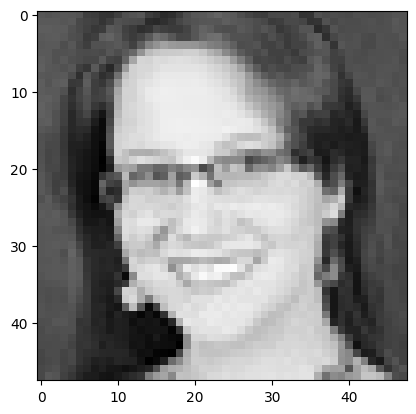

In [27]:
image = 'images/train/happy/7.jpg'
print("original image is of happy")
img = ef(image)
pred = model.predict(img)
pred_label = label[pred.argmax()]
print("model prediction is ",pred_label)
plt.imshow(img.reshape(48,48),cmap='gray')

original image is of surprise
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
model prediction is  surprise


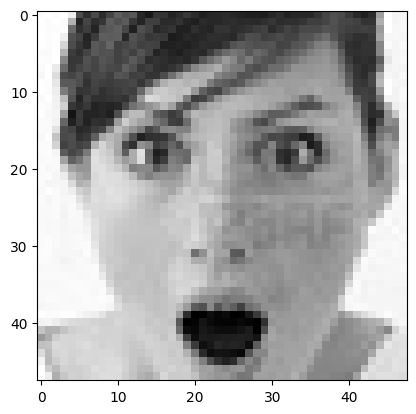

In [28]:
image = 'images/train/surprise/2475.jpg'
print("original image is of surprise")
img = ef(image)
pred = model.predict(img)
pred_label = label[pred.argmax()]
print("model prediction is ",pred_label)
plt.imshow(img.reshape(48,48),cmap='gray')

original image is of disgust
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 235ms/step
model prediction is  disgust


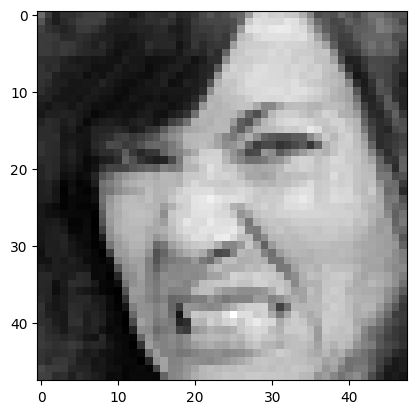

In [32]:
image = 'images/train/disgust/388.jpg'
print("original image is of disgust")
img = ef(image)
pred = model.predict(img)
pred_label = label[pred.argmax()]
print("model prediction is ",pred_label)
plt.imshow(img.reshape(48,48),cmap='gray')

original image is of angry
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step
model prediction is  angry


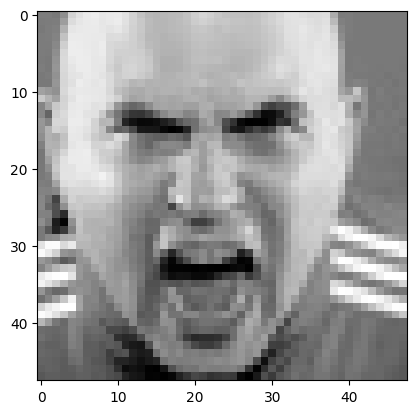

In [33]:
image = 'images/train/angry/22.jpg'
print("original image is of angry")
img = ef(image)
pred = model.predict(img)
pred_label = label[pred.argmax()]
print("model prediction is ",pred_label)
plt.imshow(img.reshape(48,48),cmap='gray')